# Core Benchmark Analysis

Notebook ini berfungsi untuk:
- Memverifikasi bahwa artefak yang dibaca sesuai dengan run yang dimaksud,
- Menyajikan hasil dalam bentuk tabel dan visualisasi yang lebih mudah ditafsirkan,
- Mendokumentasikan interpretasi teknikal terhadap performa masing-masing engine.

## Content

Alur analisis pada notebook ini disusun agar konsisten dengan logika evaluasi eksperimental, pengelompokan skenario, dan hierarki metrik. Pembacaan hasil dibagi menjadi:

1. Provenance dan desain eksperimen,
2. Klasifikasi skenario,
3. Outcome utama pada skenario operasional,
4. Validasi constraint pada skenario operasional,
5. Analisis stabilitas,
6. Matriks keputusan dan efisiensi.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

ENGINE_ORDER = ["dice_plain", "dice_constrained_native", "nn_production"]
SCENARIO_ORDER = ["default_mutable", "bmi_activity_smoking_hypertension", "bmi_activity_cholesterol", "bmi_activity", "bmi"]
ENGINE_COLORS = {"dice_plain": "#1f77b4", "dice_constrained_native": "#ff7f0e", "nn_production": "#2ca02c"}

SCENARIO_GROUPS = {
    "operational": ["default_mutable", "bmi_activity_smoking_hypertension", "bmi_activity_cholesterol", "bmi_activity", "bmi"],
}
SCENARIO_GROUP_LABELS = {
    "operational": "Operational",
}

SCENARIO_NUMERIC_COLS = [
    "target_success_rate_all_candidates",
    "plausibility_pass_rate",
    "mean_lof_score",
    "mean_changed_feature_count",
    "mean_distance_l1",
    "mean_runtime_ms",
    "immutable_violation_rate",
    "mutable_violation_rate",
]

STABILITY_NUMERIC_COLS = [
    "mean_feasible_only_jaccard_changed_features",
    "mean_feasible_only_stability_std_norm",
]


def style_metric_table(
    frame: pd.DataFrame,
    percent_cols: list[str] | None = None,
    precision: int = 3,
    hide_index: bool = False,
):
    percent_cols = percent_cols or []
    formatters = {col: lambda x: f"{x:.1%}" if pd.notna(x) else "-" for col in percent_cols if col in frame.columns}
    for col in frame.columns:
        if col in formatters:
            continue
        if pd.api.types.is_float_dtype(frame[col]):
            formatters[col] = lambda x, p=precision: f"{x:.{p}f}" if pd.notna(x) else "-"
    styled = frame.style.format(formatters)
    if hide_index:
        styled = styled.hide(axis="index")
    return styled


def extract_engine_from_source(path_like: str) -> str:
    lower = str(path_like).lower()
    for engine in ENGINE_ORDER:
        needle = f"\\{engine}\\"
        if needle in lower:
            return engine
    return "unknown"


def classify_scenario(name: str) -> str:
    for group_name, names in SCENARIO_GROUPS.items():
        if name in names:
            return group_name
    return "unknown"


def _read_jsonl(path: Path) -> list[dict]:
    rows = []
    if not path.exists():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def collect_reason_counts(comparison_root: Path) -> pd.DataFrame:
    rows = []
    for manifest_path in sorted(comparison_root.rglob("baseline_manifest.json")):
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        engine = str(manifest.get("engine") or "unknown")
        for step in manifest.get("scenario_steps", []):
            scenario = str(step.get("scenario") or "")
            run_dir = step.get("run_dir")
            if not scenario or not run_dir:
                continue
            cases = _read_jsonl(Path(run_dir) / "cases.jsonl")
            reason_counts = {}
            for case in cases:
                reason = str(case.get("reason_code") or "UNKNOWN")
                reason_counts[reason] = reason_counts.get(reason, 0) + 1
            rows.append(
                {
                    "engine": engine,
                    "scenario": scenario,
                    "reason_counts": json.dumps(reason_counts, ensure_ascii=True, sort_keys=True),
                }
            )
    return pd.DataFrame(rows)


def plot_engine_metric(
    frame: pd.DataFrame,
    column: str,
    title: str,
    ylabel: str,
    percent: bool = False,
    reference_line: float | None = None,
    reference_label: str | None = None,
):
    plot_frame = frame.set_index("engine")[[column]].reindex(ENGINE_ORDER)
    series = plot_frame[column]
    ax = series.plot(
        kind="bar",
        figsize=(8, 4),
        rot=0,
        legend=False,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in series.index],
    )
    ax.set_title(title)
    ax.set_xlabel("engine")
    ax.set_ylabel(ylabel)
    if percent:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    if reference_line is not None:
        ax.axhline(
            reference_line,
            color="#374151",
            linestyle="--",
            linewidth=1,
            label=reference_label,
        )
        if reference_label is not None:
            ax.legend()
    plt.tight_layout()
    plt.show()


In [2]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Repo root not found from notebook path.")


REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = REPO_ROOT / "experiments" / "results"
LATEST_COMPARISON_POINTER = RESULTS_ROOT / "latest" / "comparison.txt"

if not LATEST_COMPARISON_POINTER.exists():
    raise FileNotFoundError(f"Latest comparison pointer not found: {LATEST_COMPARISON_POINTER}")

COMPARISON_ROOT = Path(LATEST_COMPARISON_POINTER.read_text(encoding="utf-8").strip())
CHECKPOINT_REPORT_PATH = COMPARISON_ROOT / "checkpoint_report.md"
COMPARISON_REPORT_PATH = COMPARISON_ROOT / "comparison_report.md"
CHECKPOINT_MANIFEST_PATH = COMPARISON_ROOT / "checkpoint_manifest.json"
COMPARISON_MANIFEST_PATH = COMPARISON_ROOT / "comparison_manifest.json"
AUDIT_REPORT_PATH = COMPARISON_ROOT / "audit_report.json"
COMBINED_DIR = COMPARISON_ROOT / "combined"

SCENARIO_SUMMARY_PATH = COMBINED_DIR / "scenario_summary.csv"
STABILITY_SUMMARY_PATH = COMBINED_DIR / "stability_summary.csv"
CANDIDATES_PATH = COMBINED_DIR / "candidates.csv"
INPUTS_PATH = COMBINED_DIR / "inputs.csv"

comparison_manifest = json.loads(COMPARISON_MANIFEST_PATH.read_text(encoding="utf-8"))
checkpoint_manifest = json.loads(CHECKPOINT_MANIFEST_PATH.read_text(encoding="utf-8"))
audit_report = json.loads(AUDIT_REPORT_PATH.read_text(encoding="utf-8"))

scenario_df = pd.read_csv(SCENARIO_SUMMARY_PATH) if SCENARIO_SUMMARY_PATH.exists() else pd.DataFrame()
stability_df = pd.read_csv(STABILITY_SUMMARY_PATH) if STABILITY_SUMMARY_PATH.exists() else pd.DataFrame()
candidates_df = pd.read_csv(CANDIDATES_PATH) if CANDIDATES_PATH.exists() else pd.DataFrame()
inputs_df = pd.read_csv(INPUTS_PATH) if INPUTS_PATH.exists() else pd.DataFrame()
reason_counts_df = collect_reason_counts(COMPARISON_ROOT)

for col in SCENARIO_NUMERIC_COLS:
    if col in scenario_df.columns:
        scenario_df[col] = pd.to_numeric(scenario_df[col], errors="coerce")

for col in STABILITY_NUMERIC_COLS:
    if col in stability_df.columns:
        stability_df[col] = pd.to_numeric(stability_df[col], errors="coerce")

print(f"Comparison root: {COMPARISON_ROOT}")
print(f"Scenario rows: {len(scenario_df)} | Stability rows: {len(stability_df)}")
print(f"Candidate rows: {len(candidates_df)} | Input rows: {len(inputs_df)}")

Comparison root: D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260612_234825
Scenario rows: 15 | Stability rows: 3
Candidate rows: 364 | Input rows: 300


## 1. Provenance and Experimental Design

In [3]:
design_summary = pd.DataFrame(
    [
        {
            "engines": ", ".join(comparison_manifest.get("engines", [])),
            "scenario_count": len(comparison_manifest.get("scenario_configs", [])),
            "scenario_limit": comparison_manifest.get("scenario_limit"),
            "stability_limit": comparison_manifest.get("stability_limit"),
            "repeat_count": comparison_manifest.get("repeat_count"),
            "scenario_timeout_seconds": comparison_manifest.get("scenario_timeout_seconds"),
            "stability_timeout_seconds": comparison_manifest.get("stability_timeout_seconds"),
            "checkpoint_ok": checkpoint_manifest.get("ok"),
            "fail_on_timeout": audit_report.get("fail_on_timeout"),
        }
    ]
)
display(design_summary.T.rename(columns={0: "value"}))

,value
engines,"dice_plain, dice_constrained_native, nn_produc..."
scenario_count,5
scenario_limit,20
stability_limit,10
repeat_count,5
scenario_timeout_seconds,180
stability_timeout_seconds,180
checkpoint_ok,True
fail_on_timeout,True


## 2. Klasifikasi Skenario

In [4]:
scenario_catalog = pd.DataFrame([
    {
        "scenario": name,
        "group": group_name,
        "group_label": SCENARIO_GROUP_LABELS.get(group_name, group_name),
    }
    for group_name, names in SCENARIO_GROUPS.items()
    for name in names
]).sort_values(["group", "scenario"]).reset_index(drop=True)

display(scenario_catalog.style.hide(axis="index"))

scenario,group,group_label
bmi,operational,Operational
bmi_activity,operational,Operational
bmi_activity_cholesterol,operational,Operational
bmi_activity_smoking_hypertension,operational,Operational
default_mutable,operational,Operational


## 3. Outcome Utama pada Skenario Operasional

engine,scenario,success_rate,plausibility_pass_rate,mean_lof_score,mean_changed_feature_count,mean_distance_l1,mean_runtime_ms,reason_counts
dice_plain,default_mutable,100.0%,60.0%,1.421,1.450,0.061,175.850,"{""OK"": 20}"
dice_constrained_native,default_mutable,100.0%,61.1%,1.492,1.500,0.073,162.300,"{""OK"": 18, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 2}"
nn_production,default_mutable,100.0%,100.0%,1.124,1.077,0.022,632.600,"{""MEDICAL_RULE_VIOLATION_ONLY"": 7, ""OK"": 13}"
dice_plain,bmi_activity_smoking_hypertension,100.0%,60.0%,1.421,1.450,0.061,173.250,"{""OK"": 20}"
dice_constrained_native,bmi_activity_smoking_hypertension,100.0%,50.0%,1.535,1.444,0.069,153.300,"{""OK"": 18, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 2}"
nn_production,bmi_activity_smoking_hypertension,100.0%,100.0%,1.124,1.077,0.022,597.350,"{""MEDICAL_RULE_VIOLATION_ONLY"": 7, ""OK"": 13}"
dice_plain,bmi_activity_cholesterol,100.0%,60.0%,1.421,1.450,0.061,157.350,"{""OK"": 20}"
dice_constrained_native,bmi_activity_cholesterol,100.0%,71.4%,1.414,1.357,0.046,165.100,"{""OK"": 14, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 6}"
nn_production,bmi_activity_cholesterol,100.0%,100.0%,1.129,1.000,0.013,441.850,"{""MEDICAL_RULE_VIOLATION_ONLY"": 7, ""OK"": 12, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 1}"
dice_plain,bmi_activity,100.0%,60.0%,1.421,1.450,0.061,158.100,"{""OK"": 20}"


engine,success_rate,plausibility_pass_rate,mean_lof_score,mean_changed_feature_count,mean_distance_l1,mean_runtime_ms
dice_plain,100.0%,60.0%,1.421,1.450,0.061,165.990
dice_constrained_native,100.0%,63.7%,1.455,1.317,0.050,151.700
nn_production,100.0%,100.0%,1.127,1.031,0.017,485.040


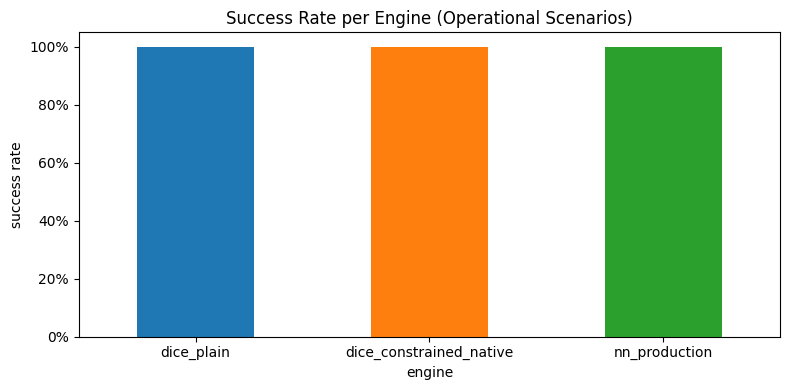

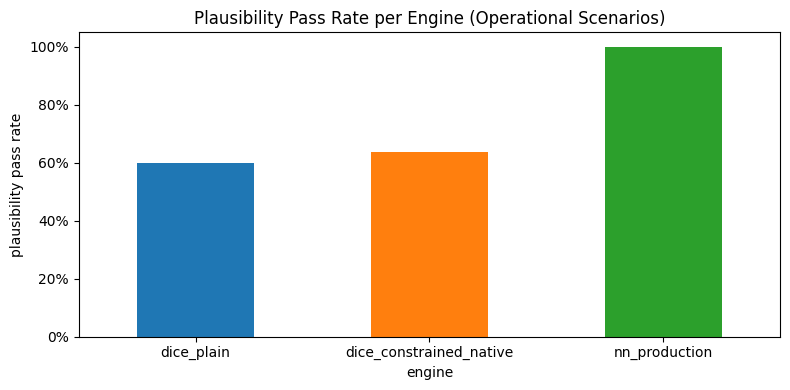

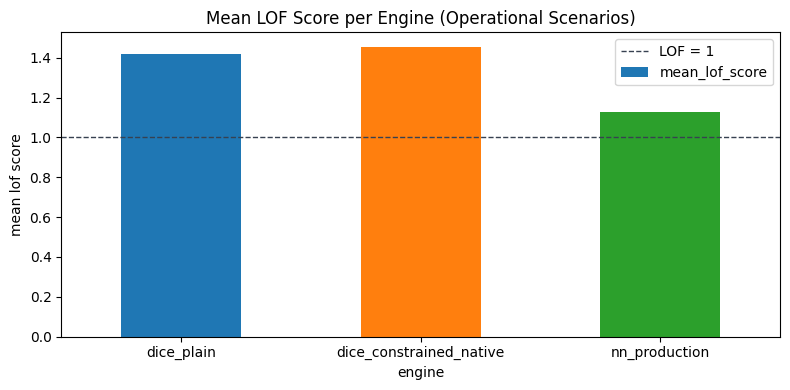

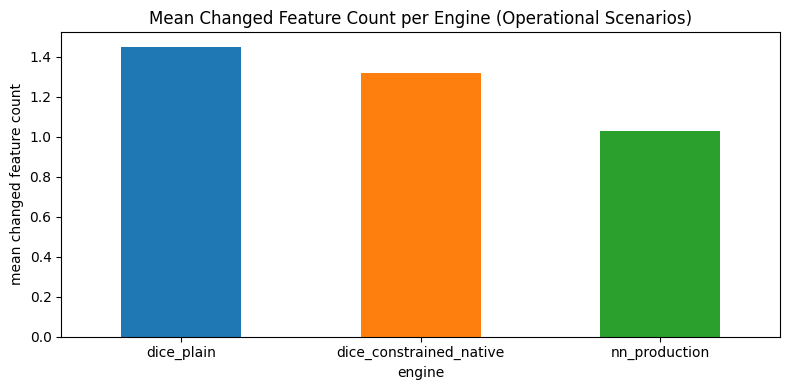

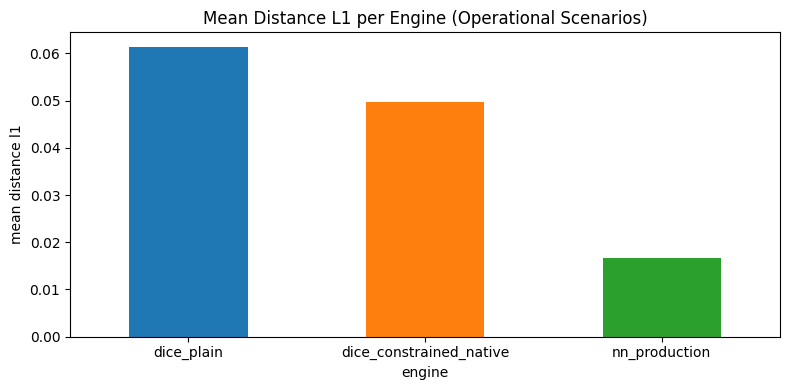

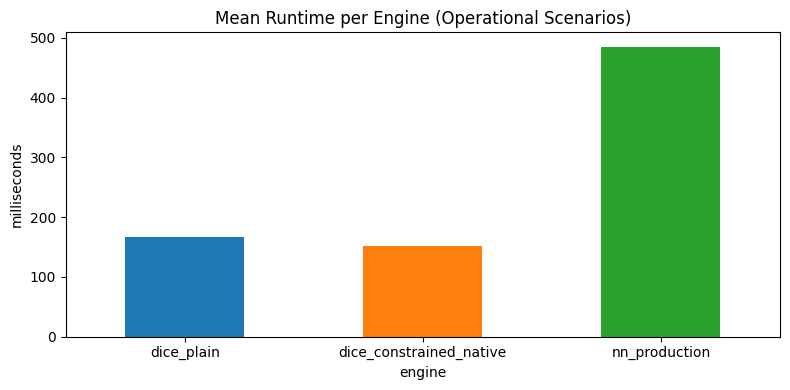

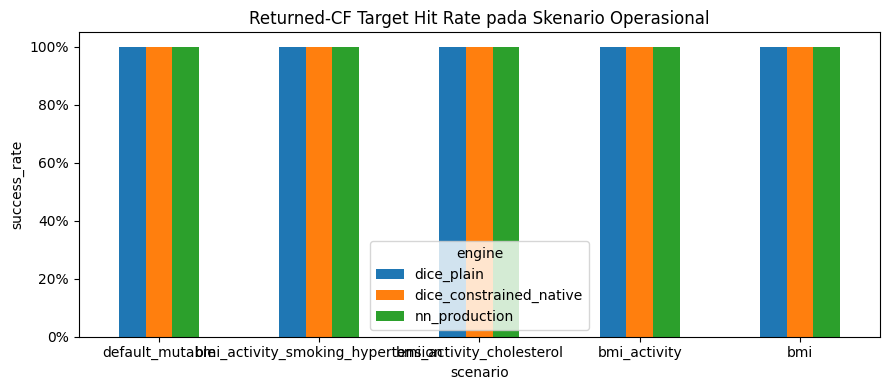

In [5]:
scenario_view = scenario_df.copy()
if not scenario_view.empty:
    scenario_view["engine"] = pd.Categorical(
        scenario_view["source_file"].map(extract_engine_from_source),
        categories=ENGINE_ORDER,
        ordered=True,
    )
    scenario_view["scenario_group"] = scenario_view["scenario"].map(classify_scenario)
    scenario_view["scenario_group_label"] = scenario_view["scenario_group"].map(lambda x: SCENARIO_GROUP_LABELS.get(x,
    x))
    scenario_view["scenario"] = pd.Categorical(scenario_view["scenario"], categories=SCENARIO_ORDER, ordered=True)

    operational_outcome_view = scenario_view.loc[
        scenario_view["scenario_group"] == "operational",
        [
            "engine",
            "scenario",
            "target_success_rate_all_candidates",
            "plausibility_pass_rate",
            "mean_lof_score",
            "mean_changed_feature_count",
            "mean_distance_l1",
            "mean_runtime_ms",
        ],
    ].sort_values(["scenario", "engine"]).reset_index(drop=True)
    operational_outcome_view = operational_outcome_view.rename(columns={"target_success_rate_all_candidates": "success_rate"})
    operational_outcome_view = operational_outcome_view.merge(
        reason_counts_df,
        on=["engine", "scenario"],
        how="left",
    )
    operational_outcome_view["reason_counts"] = operational_outcome_view["reason_counts"].fillna("{}")
    operational_outcome_view = operational_outcome_view[
        [
            "engine",
            "scenario",
            "success_rate",
            "plausibility_pass_rate",
            "mean_lof_score",
            "mean_changed_feature_count",
            "mean_distance_l1",
            "mean_runtime_ms",
            "reason_counts",
        ]
    ]

    display(
        style_metric_table(
            operational_outcome_view,
            percent_cols=["success_rate", "plausibility_pass_rate"],
            hide_index=True,
        )
    )

    operational_engine_summary = (
        operational_outcome_view.groupby("engine", as_index=False)
        .agg(
            success_rate=("success_rate", "mean"),
            plausibility_pass_rate=("plausibility_pass_rate", "mean"),
            mean_lof_score=("mean_lof_score", "mean"),
            mean_changed_feature_count=("mean_changed_feature_count", "mean"),
            mean_distance_l1=("mean_distance_l1", "mean"),
            mean_runtime_ms=("mean_runtime_ms", "mean"),
        )
        .assign(engine=lambda df: pd.Categorical(df["engine"], categories=ENGINE_ORDER, ordered=True))
        .sort_values("engine")
        .reset_index(drop=True)
    )

    display(
        style_metric_table(
            operational_engine_summary,
            percent_cols=["success_rate", "plausibility_pass_rate"],
            hide_index=True,
        )
    )

    plot_engine_metric(
        operational_engine_summary,
        "success_rate",
        "Success Rate per Engine (Operational Scenarios)",
        "success rate",
        percent=True,
    )

    plot_engine_metric(
        operational_engine_summary,
        "plausibility_pass_rate",
        "Plausibility Pass Rate per Engine (Operational Scenarios)",
        "plausibility pass rate",
        percent=True,
    )

    plot_engine_metric(
        operational_engine_summary,
        "mean_lof_score",
        "Mean LOF Score per Engine (Operational Scenarios)",
        "mean lof score",
        reference_line=1.0,
        reference_label="LOF = 1",
    )

    plot_engine_metric(
        operational_engine_summary,
        "mean_changed_feature_count",
        "Mean Changed Feature Count per Engine (Operational Scenarios)",
        "mean changed feature count",
    )

    plot_engine_metric(
        operational_engine_summary,
        "mean_distance_l1",
        "Mean Distance L1 per Engine (Operational Scenarios)",
        "mean distance l1",
    )

    plot_engine_metric(
        operational_engine_summary,
        "mean_runtime_ms",
        "Mean Runtime per Engine (Operational Scenarios)",
        "milliseconds",
    )

    operational_pivot = (
        operational_outcome_view.pivot(index="scenario", columns="engine", values="success_rate")
        .reindex(index=SCENARIO_GROUPS["operational"], columns=ENGINE_ORDER)
    )
    ax = operational_pivot.plot(
        kind="bar",
        figsize=(9, 4),
        rot=0,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in operational_pivot.columns],
    )
    ax.set_title("Returned-CF Target Hit Rate pada Skenario Operasional")
    ax.set_ylabel("success_rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()

    best_operational = operational_engine_summary.sort_values(
        ["success_rate", "plausibility_pass_rate"],
        ascending=[False, False],
    ).iloc[0]

## 4. Validasi Constraint pada Skenario Operasional

In [6]:
if not scenario_df.empty:
    constraint_summary = (
        scenario_view.loc[
            scenario_view["scenario_group"] == "operational",
            [
                "engine",
                "immutable_violation_rate",
                "mutable_violation_rate",
            ],
        ]
        .groupby("engine", as_index=False)
        .agg(
            immutable_violation_rate=("immutable_violation_rate", "mean"),
            mutable_violation_rate=("mutable_violation_rate", "mean"),
        )
    )

    validity_by_engine = constraint_summary.set_index("engine").reindex(ENGINE_ORDER)
    mandatory_validity_rows = []
    for metric in ["immutable_violation_rate", "mutable_violation_rate"]:
        row = {"Metric": metric, "Required Value": "0%"}
        row.update({engine: f"{validity_by_engine.loc[engine, metric]:.1%}" for engine in ENGINE_ORDER})
        mandatory_validity_rows.append(row)

    mandatory_validity_table = pd.DataFrame(mandatory_validity_rows)
    display(mandatory_validity_table.style.hide(axis="index"))

    all_zero = bool((constraint_summary[[
        "immutable_violation_rate",
        "mutable_violation_rate",
    ]] == 0).all().all())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23392\612648865.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("engine", as_index=False)


Metric,Required Value,dice_plain,dice_constrained_native,nn_production
immutable_violation_rate,0%,55.0%,0.0%,0.0%
mutable_violation_rate,0%,60.0%,0.0%,0.0%


## 5. Analisis Stabilitas

engine,mean_feasible_only_jaccard_changed_features,mean_feasible_only_stability_std_norm
dice_plain,42.1%,0.199
dice_constrained_native,78.2%,0.106
nn_production,100.0%,0.000


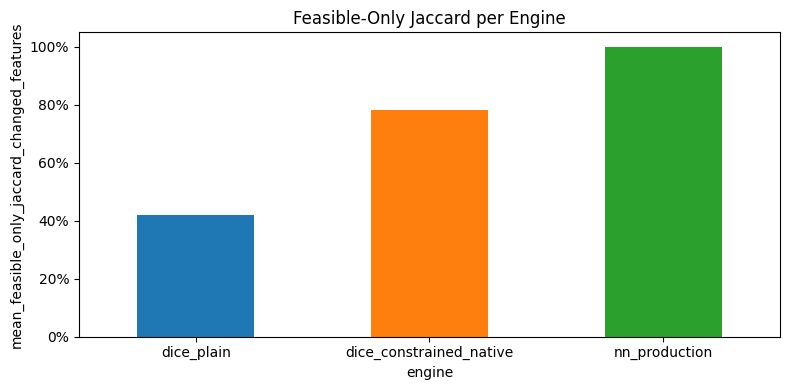

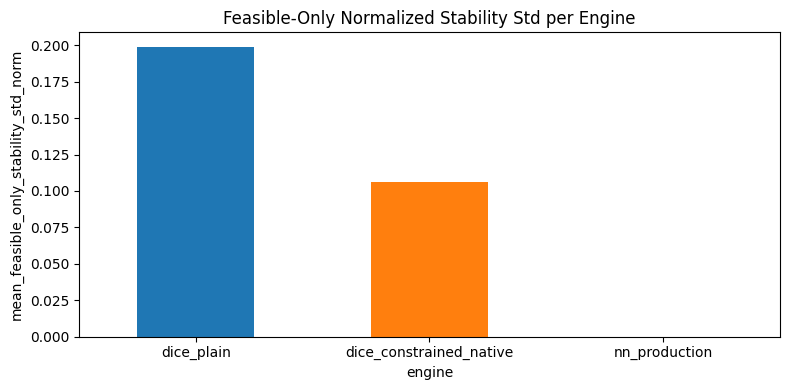

In [7]:
if not stability_df.empty:
    stability_view = stability_df.copy()
    stability_view["engine"] = pd.Categorical(
        stability_view["source_file"].map(extract_engine_from_source),
        categories=ENGINE_ORDER,
        ordered=True,
    )
    stability_view = stability_view[[
        "engine",
        "mean_feasible_only_jaccard_changed_features",
        "mean_feasible_only_stability_std_norm",
    ]].sort_values("engine").reset_index(drop=True)

    display(
        style_metric_table(
            stability_view,
            percent_cols=[
                "mean_feasible_only_jaccard_changed_features",
            ],
            hide_index=True,
        )
    )

    jaccard_plot = (
        stability_view.set_index("engine")["mean_feasible_only_jaccard_changed_features"]
        .reindex(ENGINE_ORDER)
    )
    ax = jaccard_plot.plot(
        kind="bar",
        figsize=(8, 4),
        rot=0,
        legend=False,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in jaccard_plot.index],
    )
    ax.set_title("Feasible-Only Jaccard per Engine")
    ax.set_xlabel("engine")
    ax.set_ylabel("mean_feasible_only_jaccard_changed_features")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()

    std_plot = (
        stability_view.set_index("engine")["mean_feasible_only_stability_std_norm"]
        .reindex(ENGINE_ORDER)
    )
    ax = std_plot.plot(
        kind="bar",
        figsize=(8, 4),
        rot=0,
        legend=False,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in std_plot.index],
    )
    ax.set_title("Feasible-Only Normalized Stability Std per Engine")
    ax.set_xlabel("engine")
    ax.set_ylabel("mean_feasible_only_stability_std_norm")
    plt.tight_layout()
    plt.show()

    best_stability = stability_view.sort_values(
        ["mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"],
        ascending=[False, True],
    ).iloc[0]
    stability_note = (
        f"**Takeaway stabilitas.** Engine yang paling kuat pada stabilitas saat ini adalah**{best_stability['engine']}**, "
        f"dengan `Jaccard` {best_stability['mean_feasible_only_jaccard_changed_features']:.1%} dan "
        f"`std_norm` {best_stability['mean_feasible_only_stability_std_norm']:.3f}."
    )

## 6. Matriks Keputusan dan Efisiensi

In [8]:
scenario_engine_summary = pd.DataFrame()
if not scenario_df.empty:
    scenario_engine_summary = (
        scenario_df.assign(
            engine=scenario_df["source_file"].map(extract_engine_from_source),
            scenario_group=scenario_df["scenario"].map(classify_scenario),
        )
        .loc[lambda df: df["scenario_group"] == "operational"]
        .groupby("engine", as_index=False)
        .agg(
            success_rate=("target_success_rate_all_candidates", "mean"),
            plausibility_pass_rate=("plausibility_pass_rate", "mean"),
            mean_lof_score=("mean_lof_score", "mean"),
            mean_changed_feature_count=("mean_changed_feature_count", "mean"),
            mean_distance_l1=("mean_distance_l1", "mean"),
            mean_runtime_ms=("mean_runtime_ms", "mean"),
            immutable_violation_rate=("immutable_violation_rate", "mean"),
            mutable_violation_rate=("mutable_violation_rate", "mean"),
        )
    )

stability_engine_summary = pd.DataFrame()
if not stability_df.empty:
    stability_engine_summary = (
        stability_df.assign(engine=stability_df["source_file"].map(extract_engine_from_source))[[
            "engine",
            "mean_feasible_only_jaccard_changed_features",
            "mean_feasible_only_stability_std_norm",
        ]].copy()
    )

if not scenario_engine_summary.empty:
    decision_matrix = scenario_engine_summary.merge(stability_engine_summary, on="engine", how="left")
    decision_matrix["engine"] = pd.Categorical(decision_matrix["engine"], categories=ENGINE_ORDER, ordered=True)
    decision_matrix = decision_matrix.sort_values("engine").reset_index(drop=True)

    decision_matrix = decision_matrix[[
        "engine",
        "success_rate",
        "plausibility_pass_rate",
        "mean_lof_score",
        "mean_changed_feature_count",
        "mean_distance_l1",
        "mean_runtime_ms",
        "immutable_violation_rate",
        "mutable_violation_rate",
        "mean_feasible_only_jaccard_changed_features",
        "mean_feasible_only_stability_std_norm",
    ]]

    display(
        style_metric_table(
            decision_matrix,
            percent_cols=[
                "success_rate",
                "plausibility_pass_rate",
                "immutable_violation_rate",
                "mutable_violation_rate",
                "mean_feasible_only_jaccard_changed_features",
            ],
            hide_index=True,
        )
    )

    top_operational = decision_matrix.sort_values("success_rate", ascending=False).iloc[0]
    top_runtime = decision_matrix.sort_values("mean_runtime_ms", ascending=True).iloc[0]
    top_stability = decision_matrix.sort_values(
        ["mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"],
        ascending=[False, True],
    ).iloc[0]

engine,success_rate,plausibility_pass_rate,mean_lof_score,mean_changed_feature_count,mean_distance_l1,mean_runtime_ms,immutable_violation_rate,mutable_violation_rate,mean_feasible_only_jaccard_changed_features,mean_feasible_only_stability_std_norm
dice_plain,100.0%,60.0%,1.421,1.450,0.061,165.990,55.0%,60.0%,42.1%,0.199
dice_constrained_native,100.0%,63.7%,1.455,1.317,0.050,151.700,0.0%,0.0%,78.2%,0.106
nn_production,100.0%,100.0%,1.127,1.031,0.017,485.040,0.0%,0.0%,100.0%,0.000
